# Preparation

In [1]:
MODEL_SAVE_PATH = "../../models/model-bn-c64-c128-c256-c256-d256.keras"
FEATURES_PATH = "../../evaluations/test-all.npz"
RANDOM_STATE = 42

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Load model & features

In [2]:
import tensorflow as tf
model = tf.keras.models.load_model(MODEL_SAVE_PATH)
with np.load(FEATURES_PATH) as data:
    features = data['features']
    labels = data['labels']

print("Features and labels loaded successfully.")

Features and labels loaded successfully.


# Evaluation

45/45 [==============================] - 3s 41ms/step


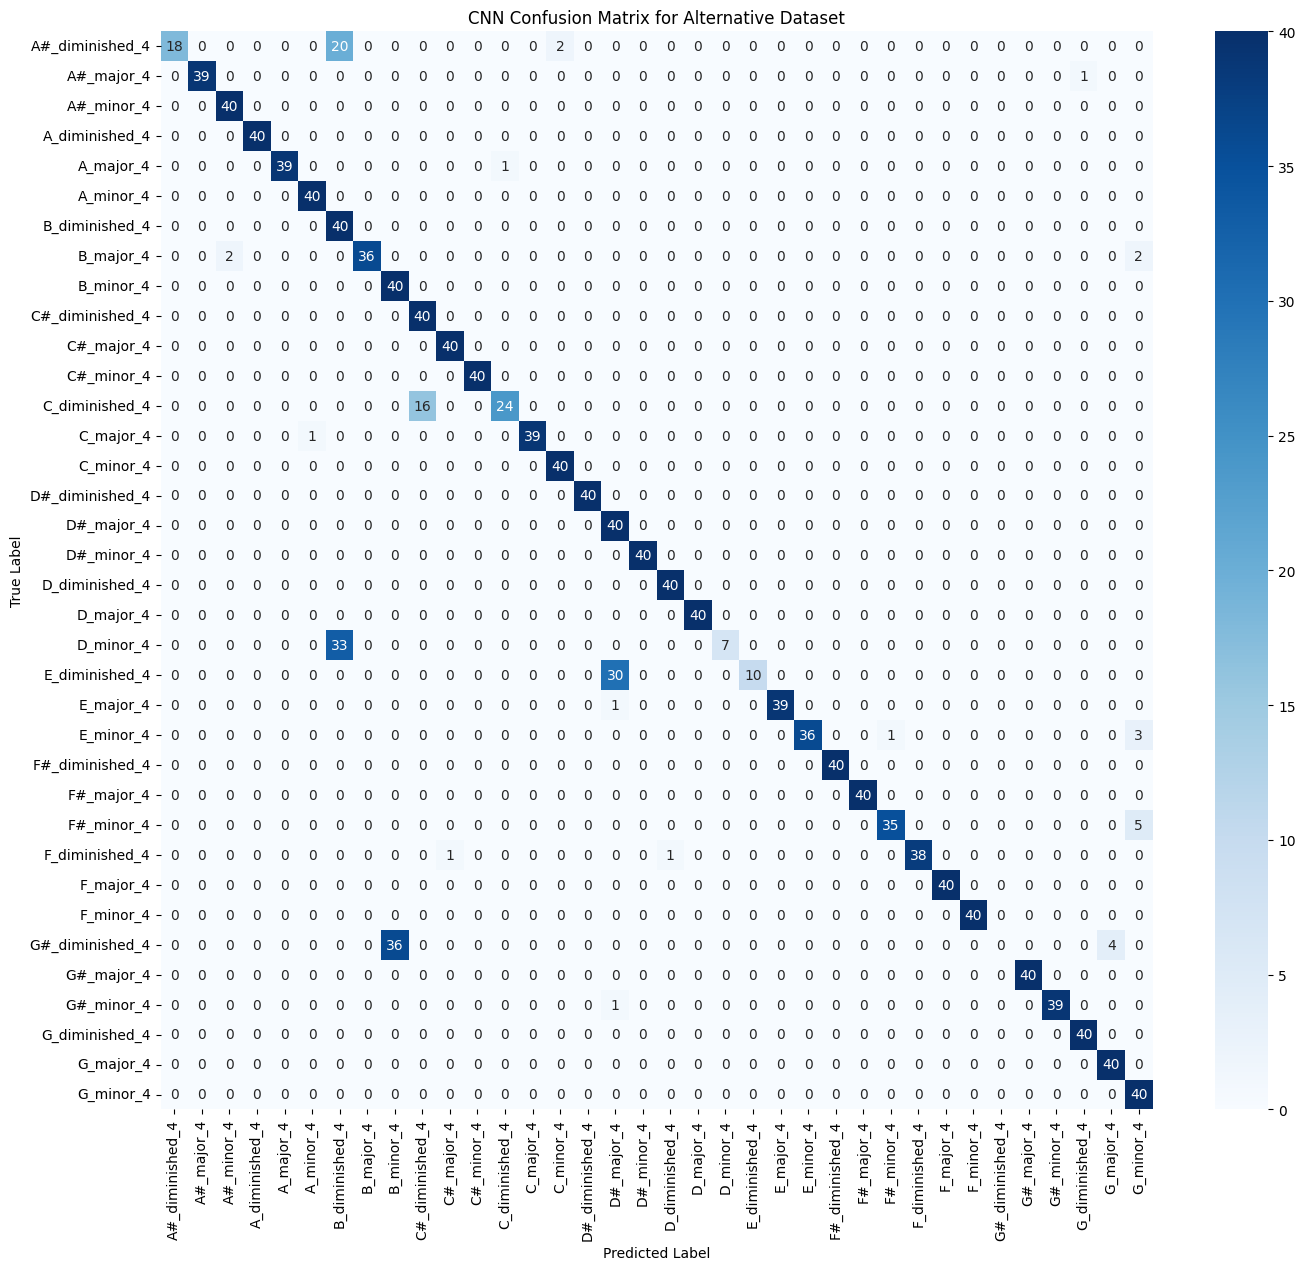

CNN Test Accuracy on Alternative Dataset: 0.8881944444444444

CNN Classification Report for Alternative Dataset:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.45      0.62        40
     A#_major_4       1.00      0.97      0.99        40
     A#_minor_4       0.95      1.00      0.98        40
 A_diminished_4       1.00      1.00      1.00        40
      A_major_4       1.00      0.97      0.99        40
      A_minor_4       0.98      1.00      0.99        40
 B_diminished_4       0.43      1.00      0.60        40
      B_major_4       1.00      0.90      0.95        40
      B_minor_4       0.53      1.00      0.69        40
C#_diminished_4       0.71      1.00      0.83        40
     C#_major_4       0.98      1.00      0.99        40
     C#_minor_4       1.00      1.00      1.00        40
 C_diminished_4       0.96      0.60      0.74        40
      C_major_4       1.00      0.97      0.99        40
      C_minor_4       0.95    

/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Fit label encoder on clean labels (all classes the model was trained on)
label_encoder = LabelEncoder()
label_encoder.fit(labels)
num_classes = len(label_encoder.classes_)

# Encode noisy labels using the clean label encoder
encoded_labels = label_encoder.transform(labels)
categorical_labels = to_categorical(encoded_labels, num_classes=num_classes)

# Reshape features to add a channel dimension
features_reshaped = np.expand_dims(features, axis=-1)

# Get predictions for the noisy test set
predictions = model.predict(features_reshaped)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(categorical_labels, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm_noisy = confusion_matrix(actual_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix for Alternative Dataset')
plt.show()

# Generate classification report
accuracy_noisy = accuracy_score(actual_classes, predicted_classes)
print(f"CNN Test Accuracy on Alternative Dataset: {accuracy_noisy}")

report_noisy = classification_report(actual_classes, predicted_classes, target_names=class_labels)
print("\nCNN Classification Report for Alternative Dataset:\n", report_noisy)